# Cleaning TESS images
Below is some example code for downloading all images from one TESS frame and cleaning them
using the approach described in Alexandersen et al. 2026.

To run this notebook, you will need a Python environment with the neccessary dependencies. 
This can be set up like so:
```sh
conda create -n cleany python=3.12 numpy astropy jupyter notebook astroquery ccdproc sep
conda activate cleany
```

### Setup

In [1]:
%%time
# Third party imports
import os
import sys
import copy
import glob
import requests
import warnings
import matplotlib
import subprocess
import numpy as np
from pathlib import Path
from importlib import reload
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval
warnings.filterwarnings("ignore")

CPU times: user 1.55 s, sys: 59.7 ms, total: 1.61 s
Wall time: 469 ms


In [2]:
%%time
# Local imports
sys.path.append(str(Path.cwd().parent))
from cleany import imagehandler
from cleany import cleaner
reload(imagehandler)  # If you make changes to the background code, just rerun this cell to re-import, rather than killing the notebook
reload(cleaner)       # If you make changes to the background code, just rerun this cell to re-import, rather than killing the notebook

CPU times: user 319 ms, sys: 28.9 ms, total: 348 ms
Wall time: 348 ms


<module 'cleany.cleaner' from '/home/mikea/GitHub/cleany/cleany/cleaner.py'>

In [3]:
%%time
# Plot setup
matplotlib.rc("font", size=22, family="serif", weight="bold")
plt.rcParams["figure.figsize"] = [10, 4]
np.set_printoptions(suppress=True)  # Don't want scientific notation

CPU times: user 44 μs, sys: 3 μs, total: 47 μs
Wall time: 48.4 μs


In [4]:
%%time
# Define a function that we can use to make some simple plots after each step.
def make_plots(input_data, title=""):
    """
    Make two plots of the same data.
    One has the colourbare going from the minimum to maximum data values,
    while the other uses the common ZScaleInterval to select an interval that shows
    the section of the dynamic range that most data values lie within.
    """
    fig, ax = plt.subplots(1, 2)
    # Masked pixels have np.nan values, which show up as white in imshow, which is very distracting.
    # To make the masked pixels less distracting, masked pixels will be plotted as the mean value. 
    image_data = copy.deepcopy(input_data)
    image_data[np.isnan(image_data)] = np.nanmean(image_data)
    # Left side, min to max
    im=ax[0].imshow(image_data, interpolation='nearest', cmap='gray', origin='lower',
                    vmin=np.nanmin(image_data), vmax=np.nanmax(image_data))
    fig.colorbar(im, ax=ax[0])
    ax[0].set_title("Min to max")
    # Right side, ZScaleInterval
    z1, z2 = ZScaleInterval().get_limits(image_data)
    im=ax[1].imshow(image_data, interpolation='nearest', cmap='gray', origin='lower', vmin=z1, vmax=z2)
    fig.colorbar(im, ax=ax[1])
    ax[1].set_title("ZScale")
    if title:
        fig.suptitle(f"{title}\n")

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 3.1 μs


### Get the data

In [5]:
# Define which sector/camera/ccd to look at
sector = 5
camera = 1
ccd = 4
# Define the name of the download script.
download_script = f"tesscurl_sector_{sector}_ffic.sh"
# Define where to put good, bad and cleaned data:
used_data_dir = Path("good_quality")
used_data_dir.mkdir(exist_ok=True)
unused_data_dir = Path("poor_quality")
unused_data_dir.mkdir(exist_ok=True)
data_dir = Path("cleaned")
data_dir.mkdir(exist_ok=True)

In [6]:
%%time
# Here we're going to grab the download script for all of the sector,
# filtering it to only get the camera/ccd that we want. 
with requests.get(f"https://archive.stsci.edu/missions/tess/download_scripts/sector/{download_script}") as r:
    r.raise_for_status()
    with open(download_script, 'w') as f:
        for line in r.text.splitlines():
            if f"s0005-1-4" in line:
                print(line, file=f)

CPU times: user 25.1 ms, sys: 14.7 ms, total: 39.8 ms
Wall time: 343 ms


Download all data from sector/camera/chip (ie. **40 GB** of data); will be **slow** (~30 minutes)!

In [7]:
%%time
# Run the download script to download the images. 
# This will take a while, downloading ~40 GB of data
subprocess.run(["/bin/bash", download_script])
# This wil download 1196 fits images, so be patient.

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 33.9M  100 33.9M    0     0  16.1M      0  0:00:02  0:00:02 --:--:-- 21.9M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 33.9M  100 33.9M    0     0  18.8M      0  0:00:01  0:00:01 --:--:-- 25.4M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 33.9M  100 33.9M    0     0  16.2M      0  0:00:02  0:00:02 --:--:-- 21.4M
  % Total    % Received % Xferd  Average Speed   Tim

CPU times: user 3.78 s, sys: 598 ms, total: 4.37 s
Wall time: 31min 5s


100 33.9M  100 33.9M    0     0  33.4M      0  0:00:01  0:00:01 --:--:-- 57.2M


CompletedProcess(args=['/bin/bash', 'tesscurl_sector_5_ffic.sh'], returncode=0)

In [8]:
%%time
# Split good and poor quality images.

# Originally we used the `eleanor` package to filter the images and remove ones with high background or poor image quality,
# but `eleanor` seems to not work in Python 3.12 (broken dependencies).
# So here, we will just say "These images were somehow flagged as bad, leave those out".
# If you switch to a different sector/camera/chip, you'll need to find a way identify bad images.
poor_images = Path("bad_image_names.txt").read_text().splitlines()
Path("poor_quality").mkdir(parents=True, exist_ok=True)
for f in Path(".").glob("tess*_ffic.fits"):
    if str(f) in poor_images:
        f.replace(f.parent / unused_data_dir / f.name)
        print(f"{f} moved to {(f.parent / unused_data_dir / f.name)}")
    else:
        f.replace(f.parent / used_data_dir / f.name)
        print(f"{f} moved to {(f.parent / used_data_dir / f.name)}")    

tess2018329225938-s0005-1-4-0125-s_ffic.fits moved to good_quality/tess2018329225938-s0005-1-4-0125-s_ffic.fits
tess2018342052938-s0005-1-4-0125-s_ffic.fits moved to good_quality/tess2018342052938-s0005-1-4-0125-s_ffic.fits
tess2018340092938-s0005-1-4-0125-s_ffic.fits moved to good_quality/tess2018340092938-s0005-1-4-0125-s_ffic.fits
tess2018321012938-s0005-1-4-0125-s_ffic.fits moved to good_quality/tess2018321012938-s0005-1-4-0125-s_ffic.fits
tess2018325185938-s0005-1-4-0125-s_ffic.fits moved to good_quality/tess2018325185938-s0005-1-4-0125-s_ffic.fits
tess2018334002938-s0005-1-4-0125-s_ffic.fits moved to good_quality/tess2018334002938-s0005-1-4-0125-s_ffic.fits
tess2018328055938-s0005-1-4-0125-s_ffic.fits moved to good_quality/tess2018328055938-s0005-1-4-0125-s_ffic.fits
tess2018344052937-s0005-1-4-0125-s_ffic.fits moved to good_quality/tess2018344052937-s0005-1-4-0125-s_ffic.fits
tess2018338065938-s0005-1-4-0125-s_ffic.fits moved to good_quality/tess2018338065938-s0005-1-4-0125-s_ff

### Clean the data

1108 files
Reading image 1107: good_quality/tess2018345002937-s0005-1-4-0125-s_ffic.fits
Read 1108 files!
Done!
Aligning and padding image 1107
Done
Aligning and padding image 1107
Done
Reprojecting image 1107
Done

Done!
CPU times: user 59.2 s, sys: 861 ms, total: 1min
Wall time: 1min 3s


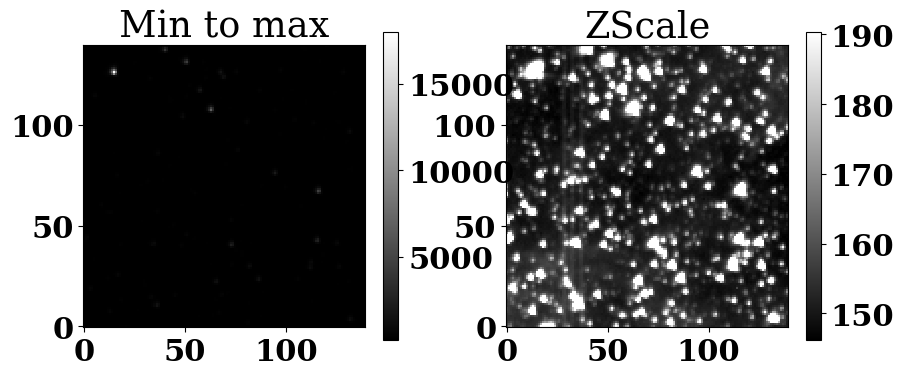

In [9]:
%%time
"""
Load in the data.

As there is 37 GB of images, your computer will need at least twice that in RAM to handle cleaning the full image array.

For this demonstration, we therefore use a 140x140 cutout, which is the same cutout that is used in
Figures 2 and 3 of Alexandersen et al. 2026, except in that work the full frame was cleaned first
and then the cutout was cut out of the full frame for the paper.
The results of using a smaller part of the chip will differ slightly from using the full frame.
"""
filenames = sorted(used_data_dir.glob("tess*_ffic.fits"))[0::]
print(len(filenames), "files")
C = cleaner.DataCleaner(filenames, extno=1, EXPTIME="EXPOSURE", EXPUNIT="d",
                        MJD_START="BJDREFI+TSTART+-2400000.5", FILTER="-Tess", verbose=False,
                        #xycuts=[44, 2092, 0, 2048]  # Removes overscan strips. Modify to use smaller area.
                        xycuts=[1594, 1734, 330, 470]  # Just do a 140x140 cutout for demo purposes, since most laptops don't enjoy reading 37 GB into memory.
                        )

# Do rough alignment (to pixel precision, without reprojection)
# TESS is usually already aligned to this level, but it's here to be sure, since the reprojection is faster if this is done first.
C.rough_align(0)
# Align by reprojecting/resampling the data onto the pixel grid of image 0 using the WCS of each image.
# (they'll thus have identical WCS afterwards and we can work in pixel space.)
C.reproject_data(0)
# Save this step (comment out if you just want the next step to re-use the C object)
C.save_cleaned(str(data_dir/"clean00"))
# Plot
make_plots(C.cleaned_data.data[440])

1108 files
Reading image 1107: cleaned/clean00_1107.fits
Read 1108 files!
Done!
Subtracting background level in image 1107
Done

Done!
CPU times: user 19.8 s, sys: 212 ms, total: 20 s
Wall time: 20 s


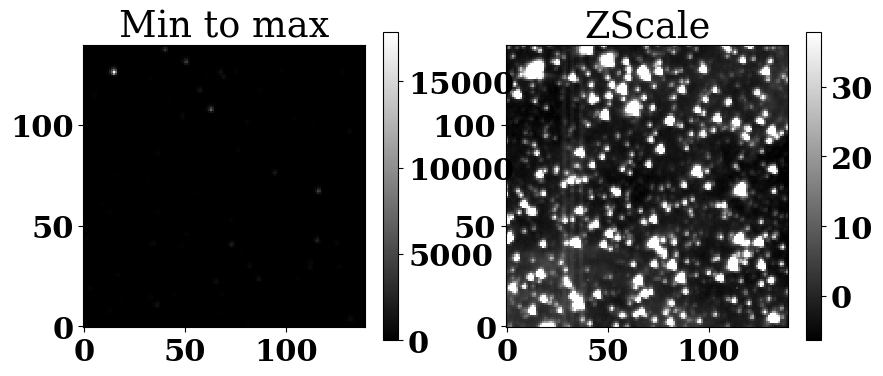

In [10]:
%%time
"""
Subtract the median background level from each images.
"""
# If you want to simply reuse the existing DataCleaner object, comment out the lines from here ...
filenames = sorted(data_dir.glob("clean00*.fits"))[0::]
print(len(filenames), "files")
C = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d",
                        MJD_START="BJDREFI+TSTART+-2400000.5", FILTER="-Tess", verbose=False)
# ... to here (you can also consider commenting out the `save_cleaned` step in the previous cell)

C.subtract_background_level(mode='median')
# Save this step (comment out if you just want the next step to re-use the C object)
C.save_cleaned(str(data_dir/"clean01"))
# Plot
make_plots(C.cleaned_data.data[440])

1108 files
Reading image 1107: cleaned/clean01_1107.fits
Read 1108 files!
Done!
0.004030612244897959

Done!
CPU times: user 16.3 s, sys: 203 ms, total: 16.5 s
Wall time: 16.5 s


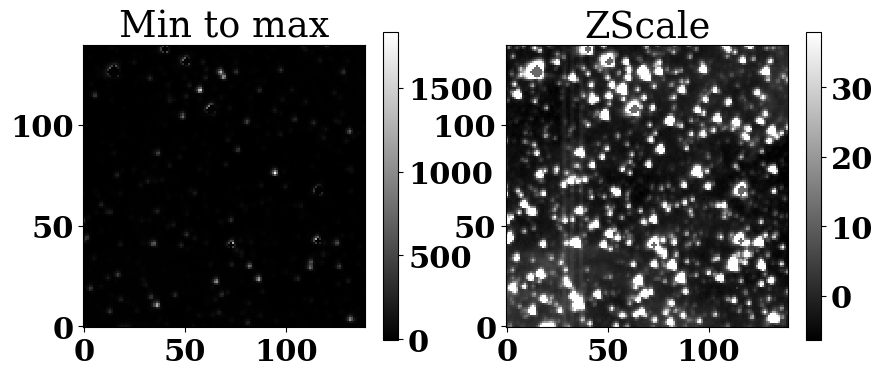

In [11]:
%%time
"""
Mask bright pixels and print the fraction of pixels masked.
"""
# If you want to simply reuse the existing DataCleaner object, comment out the lines from here ...
filenames = sorted(data_dir.glob("clean01*.fits"))[0::]
print(len(filenames), "files")
C = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d",
                        MJD_START="BJDREFI+TSTART+-2400000.5", FILTER="-Tess", verbose=False)
# ... to here (you can also consider commenting out the `save_cleaned` step in the previous cell)

C.mask_bright_sources(20000, 3.0)  # Large mask around very bright sources
C.mask_bright_sources(2000, 1.0)  # Smaller mask around lesser bright sources
# Print fraction of pixels masked
print(np.sum(np.isnan(C.cleaned_data.data))/(np.prod(np.shape(C.cleaned_data.data))))
# Save this step
C.save_cleaned(str(data_dir/"clean02"))
# Plot
make_plots(C.cleaned_data.data[440])

547 files
Reading image 546: cleaned/clean02_0546.fits
Read 547 files!
Done!
Subtracting background level in image 546
Done
Subtracting template from image 546
Done

Done!
561 files
Reading image 560: cleaned/clean02_1107.fits
Read 561 files!
Done!
Subtracting background level in image 560
Done
Subtracting template from image 560
Done

Done!
1108 files
Reading image 1107: cleaned/clean02_1107.fits
Read 1108 files!
Done!
Subtracting background level in image 1107
Done
Creating a universal template from all images.
Subtracting template

Done
CPU times: user 40 s, sys: 390 ms, total: 40.4 s
Wall time: 40.4 s


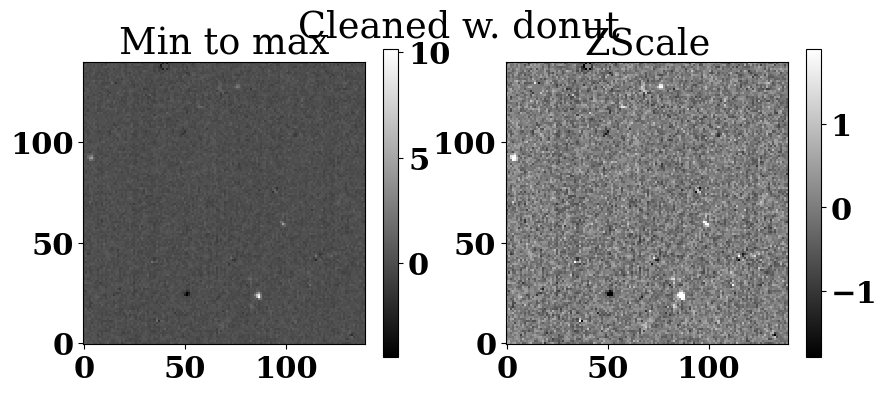

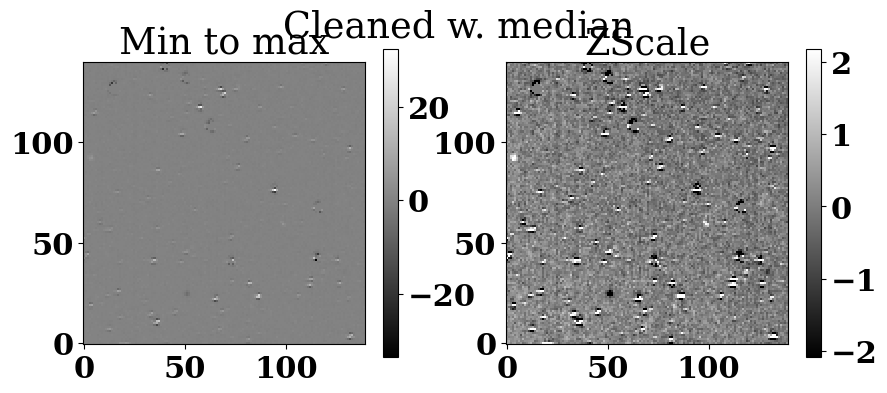

In [12]:
%%time
"""
Do the donut template subtraction.

Since there is a big time gap in the middle of the sector, the donut template should not straddle this gap. 
We thus do donut subtraction of the two halves separately.
We therefore have to read each half into separate cleaner objects, rather than using the inherited cleaner object from above.

Here we use h=40, d=10, as in the top left of Figure 3 in Alexandersen et al. 2026.
"""
h = 40
d = 10

"""First half"""
filenames = sorted(data_dir.glob("clean02*.fits"))[0:547:]
print(len(filenames), "files")
D1 = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d",
                        MJD_START="BJDREFI+TSTART+-2400000.5", FILTER="-Tess", verbose=False)
D1.subtract_background_level(mode='median')
D1.template_subtract('donut', usemean=False, ninner=h, nouter=h+d)  # ninner = h, nouter = h + d
D1.save_cleaned(str(data_dir/"clean03a"))
make_plots(D1.cleaned_data.data[440], title="Cleaned w. donut")

"""Second half"""
filenames = sorted(data_dir.glob("clean02*.fits"))[547::]
print(len(filenames), "files")
D2 = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d",
                         MJD_START="BJDREFI+TSTART+-2400000.5", FILTER="-Tess", verbose=False)
D2.subtract_background_level(mode='median')
D2.template_subtract('donut', usemean=False, ninner=h+d, nouter=h+d)
D2.save_cleaned(str(data_dir/"clean03b"))

"""Example of using the "median of all frames" template instead (as lower right panel of Figure 3 in Alexandersen et al 2026):"""
filenames = sorted(data_dir.glob("clean02*.fits"))
print(len(filenames), "files")
M = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d",
                         MJD_START="BJDREFI+TSTART+-2400000.5", FILTER="-Tess", verbose=False)
M.subtract_background_level(mode='median')
M.template_subtract('median')
make_plots(M.cleaned_data.data[440], title="Cleaned w. median")

1108 files
Reading image 1107: cleaned/clean03b_560.fits
Read 1108 files!
Done!
Subtracting background level in image 1107
Done

Done!
Subtracting background level in image 1107
Done

Done!
Subtracting background level in image 1107
Done

Done!
CPU times: user 28 s, sys: 644 ms, total: 28.7 s
Wall time: 28.7 s


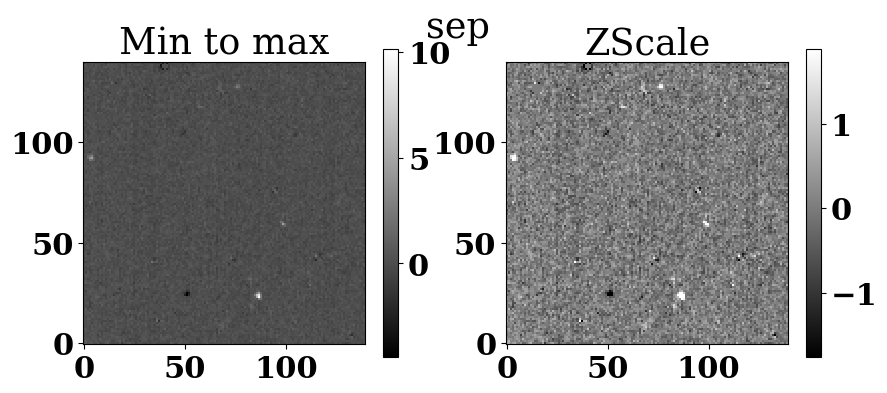

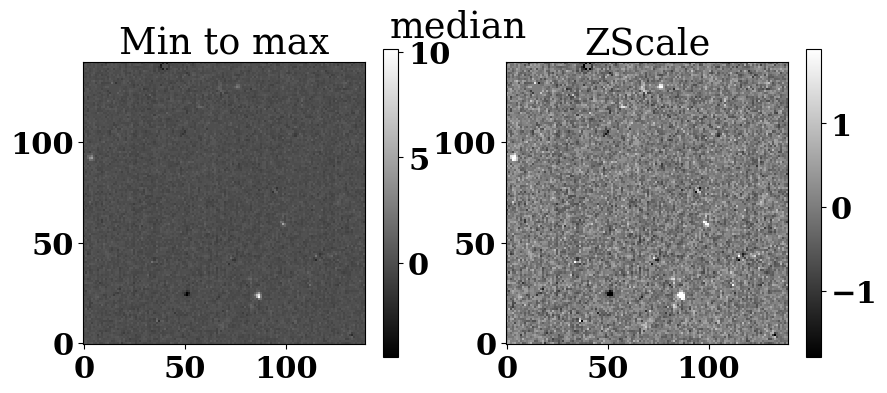

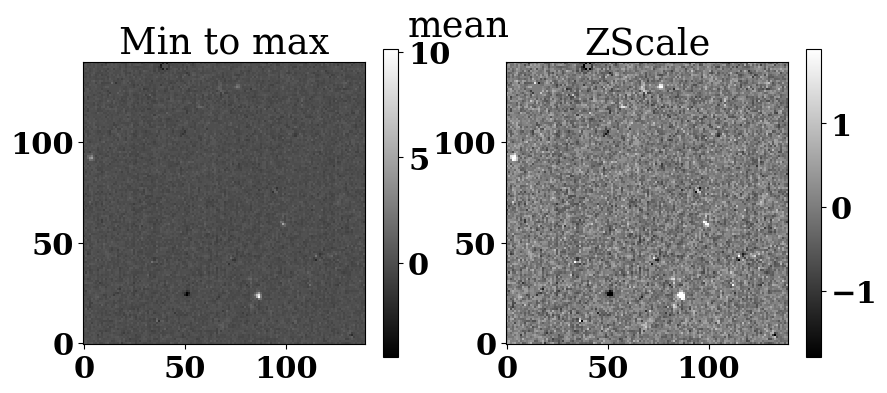

In [13]:
%%time
"""
Do the final background subtraction using three separate methods (for comparison).

- Source Extractor Background Estimator.
- median
- mean
"""
filenames = sorted(data_dir.glob("clean03*.fits"))[0::]
print(len(filenames), "files")
F1 = cleaner.DataCleaner(filenames, extno=0, EXPTIME="EXPOSURE", EXPUNIT="d",
                         MJD_START="BJDREFI+TSTART+-2400000.5", FILTER="-Tess", verbose=False)
F2=copy.deepcopy(F1)  # Much faster than re-reading the files
F3=copy.deepcopy(F1)  # Much faster than re-reading the files
# Final cleaning by subtracting a Source Extractor background estimate map from each frame.
F1.subtract_background_level(mode='sep')
F1.save_cleaned(str(data_dir/"clean04_sep"))
# Final cleaning by subtracting the median of each frame
F2.subtract_background_level(mode='median')
F2.save_cleaned(str(data_dir/"clean04_median"))
# Final cleaning by subtracting the mean of each frame
F3.subtract_background_level(mode='mean')
F3.save_cleaned(str(data_dir/"clean04_mean"))

# Plot
make_plots(F1.cleaned_data.data[440], title="sep")
make_plots(F2.cleaned_data.data[440], title="median")
make_plots(F3.cleaned_data.data[440], title="mean")